# T1 sweep result (`D:/t1`)

Plots peak fluorescence vs. dark time from the `python t1_test.py` sweep saved in
`D:/t1`. No live instrument connection needed -- everything comes from the saved
`.npy`/metadata files.

**Validity check first:** before the AWG's `write()` was fixed to raise on SCPI
errors, a long sweep could silently run past a "too many sequences defined" error
and keep saving files under the intended dark-time label while the AWG was actually
still stuck outputting an earlier sequence (see `notes.md` / the conversation this
was found in -- confirmed for real: several files in this exact directory secretly
contain a different dark time than their filename claims). Each file's *actual* dark
time can be independently recovered from its own timetable (the AWG sequence's total
period is `10us polarize + dark_time_us + 0.3us readout`, so measuring the mean
inter-trigger gap and solving for `dark_time_us` reveals what was really played,
regardless of what the filename says) -- so every file is checked against that before
being trusted for the plot below.

In [1]:
import os
import re

import numpy as np
import matplotlib.pyplot as plt

from rtb2004 import make_t_from_metadata

DATA_DIR = "D:/t1"
POLARIZE_US = 10.0
READOUT_US = 0.3
MISMATCH_TOLERANCE_US = 0.5  # how far implied vs. claimed dark time can differ
                              # before it's flagged as corrupted

## Discover and validate every sweep point

In [2]:
def find_dark_time_files(data_dir):
    """(dark_time_us, name) for every '<N>us.npy' file in data_dir, sorted."""
    pattern = re.compile(r"^(\d+)us\.npy$")
    found = []
    for fname in os.listdir(data_dir):
        m = pattern.match(fname)
        if m:
            found.append((int(m.group(1)), fname[:-4]))
    return sorted(found)


def implied_dark_time_us(data_dir, name):
    """Actual dark time this file's own timetable implies, from its mean
    inter-trigger gap -- independent of whatever the filename claims."""
    timetable_s = np.load(f"{data_dir}/{name}_timetable.npy")
    mean_gap_us = np.diff(timetable_s).mean() * 1e6
    return mean_gap_us - POLARIZE_US - READOUT_US


all_files = find_dark_time_files(DATA_DIR)
valid_files = []
corrupted_files = []
for claimed_us, name in all_files:
    implied_us = implied_dark_time_us(DATA_DIR, name)
    if abs(implied_us - claimed_us) > MISMATCH_TOLERANCE_US:
        corrupted_files.append((claimed_us, name, implied_us))
    else:
        valid_files.append((claimed_us, name))

print(f"found {len(all_files)} points total: {len(valid_files)} valid, "
      f"{len(corrupted_files)} corrupted (filename doesn't match actual timing)")
if corrupted_files:
    from collections import defaultdict
    groups = defaultdict(list)
    for claimed_us, name, implied_us in corrupted_files:
        groups[round(implied_us)].append(claimed_us)
    print("\ncorrupted files, grouped by what they actually measured:")
    for implied_us, claimed_list in sorted(groups.items()):
        print(f"  actually {implied_us}us, but labeled: {sorted(claimed_list)}")
    print("\n(excluded from the plot/fit below -- re-run these points with "
          "t1_test.py's start_after_us to fill them back in)")

found 180 points total: 82 valid, 98 corrupted (filename doesn't match actual timing)

corrupted files, grouped by what they actually measured:
  actually 32us, but labeled: [33, 34, 36, 37, 38, 40, 41, 42, 44, 46, 47, 49, 51, 52, 54, 56, 58, 60, 62, 64, 67, 69, 71, 74, 77, 79, 82, 85, 88, 91, 94, 98, 101, 105, 108, 112, 116, 120, 125, 129, 134, 138, 143, 148, 153, 159, 164, 170, 176, 183, 189, 196, 203, 210, 217, 225, 233, 241, 249, 258, 267, 277, 287, 297, 307, 318, 329, 341, 353, 365, 378, 392, 406, 420, 435, 450, 466, 482, 499, 517, 535, 554, 574, 594, 615, 637, 659, 683, 707, 732, 758, 784, 812, 841, 870, 901, 933, 966]

(excluded from the plot/fit below -- re-run these points with t1_test.py's start_after_us to fill them back in)


## Peak fluorescence vs. dark time (valid points only)

In [3]:
def load_signal_trace(data_dir, name):
    waveform = np.load(f"{data_dir}/{name}.npy")
    t_s = make_t_from_metadata(f"{data_dir}/{name}_metadata.txt")
    signal_mean = waveform.mean(axis=0)
    signal_sem = waveform.std(axis=0) / np.sqrt(len(waveform))
    return t_s, signal_mean, signal_sem, len(waveform)


peak_dark_times_us = []
peak_values = []
peak_errs = []

for dark_time_us, name in valid_files:
    t_s, signal_mean, signal_sem, n_signal = load_signal_trace(DATA_DIR, name)
    peak_idx = np.argmin(signal_mean)  # negative-going = more fluorescence
    peak_dark_times_us.append(dark_time_us)
    peak_values.append(signal_mean[peak_idx])
    peak_errs.append(signal_sem[peak_idx])

peak_dark_times_us = np.array(peak_dark_times_us, dtype=float)
peak_values = np.array(peak_values)
peak_errs = np.array(peak_errs)

print(f"{len(peak_dark_times_us)} valid points, "
      f"{peak_dark_times_us.min():.0f} to {peak_dark_times_us.max():.0f} us")

82 valid points, 1 to 10000 us


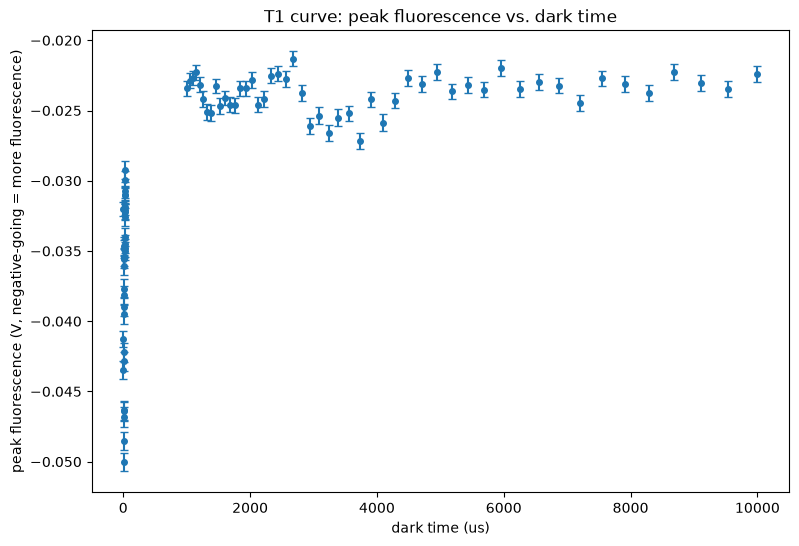

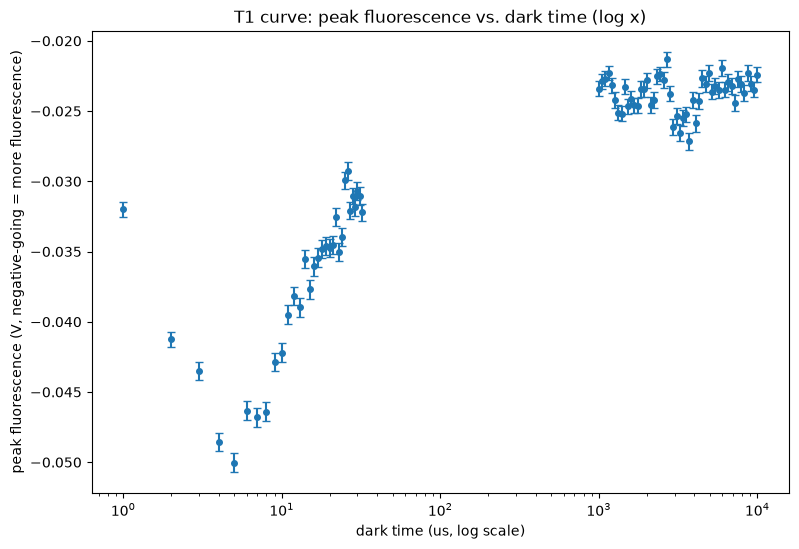

In [4]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.errorbar(peak_dark_times_us, peak_values, yerr=peak_errs, fmt="o", ms=4, capsize=3)
ax.set_xlabel("dark time (us)")
ax.set_ylabel("peak fluorescence (V, negative-going = more fluorescence)")
ax.set_title("T1 curve: peak fluorescence vs. dark time")
plt.show()

fig, ax = plt.subplots(figsize=(9, 6))
ax.errorbar(peak_dark_times_us, peak_values, yerr=peak_errs, fmt="o", ms=4, capsize=3)
ax.set_xscale("log")
ax.set_xlabel("dark time (us, log scale)")
ax.set_ylabel("peak fluorescence (V, negative-going = more fluorescence)")
ax.set_title("T1 curve: peak fluorescence vs. dark time (log x)")
plt.show()

## Exponential fit (excluding the short-dark-time rise)

Fits `y(t) = A * exp(-t / tau) + C`, using only valid points with dark time >
`MIN_FIT_DARK_TIME_US` -- the 1-3us stretch is the fast shelving/charge-state-recovery
rise, not part of the actual T1 decay, so it's excluded rather than biasing the fit
(same convention as `t1_test.ipynb`).

In [5]:
from scipy.optimize import curve_fit

def exp_decay(t, A, tau, C):
    return A * np.exp(-t / tau) + C


MIN_FIT_DARK_TIME_US = 3

fit_mask = peak_dark_times_us > MIN_FIT_DARK_TIME_US
fit_dark_times_us = peak_dark_times_us[fit_mask]
fit_values = peak_values[fit_mask]
fit_errs = peak_errs[fit_mask]
excluded_dark_times_us = peak_dark_times_us[~fit_mask]
excluded_values = peak_values[~fit_mask]

p0 = [fit_values[0] - fit_values[-1], 50.0, fit_values[-1]]
popt, pcov = curve_fit(exp_decay, fit_dark_times_us, fit_values, p0=p0,
                       sigma=fit_errs, absolute_sigma=True, maxfev=10000)
perr = np.sqrt(np.diag(pcov))

A_fit, tau_fit, C_fit = popt
A_err, tau_err, C_err = perr

print(f"fit uses {len(fit_dark_times_us)} points, dark time > {MIN_FIT_DARK_TIME_US}us "
      f"({fit_dark_times_us.min():.0f} to {fit_dark_times_us.max():.0f} us)")
print(f"A (amplitude)      = {A_fit:+.5f} +/- {A_err:.5f} V")
print(f"tau (T1)           = {tau_fit:.2f} +/- {tau_err:.2f} us")
print(f"C (offset/plateau) = {C_fit:+.5f} +/- {C_err:.5f} V")

fit uses 79 points, dark time > 3us (4 to 10000 us)
A (amplitude)      = -0.03137 +/- 0.00052 V
tau (T1)           = 18.71 +/- 0.44 us
C (offset/plateau) = -0.02373 +/- 0.00008 V


C:\Users\codin\AppData\Local\Temp\ipykernel_19944\578026588.py:4: RuntimeWarning: overflow encountered in exp
  return A * np.exp(-t / tau) + C


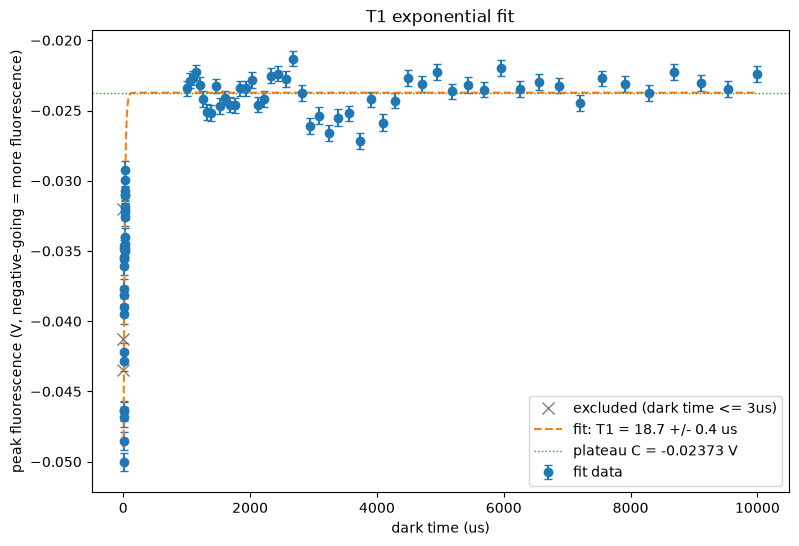

In [6]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(excluded_dark_times_us, excluded_values, "x", color="gray", ms=8,
        label=f"excluded (dark time <= {MIN_FIT_DARK_TIME_US}us)")
ax.errorbar(fit_dark_times_us, fit_values, yerr=fit_errs, fmt="o", color="C0",
            capsize=3, label="fit data")

t_smooth = np.linspace(fit_dark_times_us.min(), fit_dark_times_us.max(), 500)
ax.plot(t_smooth, exp_decay(t_smooth, *popt), "C1--",
        label=f"fit: T1 = {tau_fit:.1f} +/- {tau_err:.1f} us")
ax.axhline(C_fit, color="C2", ls=":", lw=1, label=f"plateau C = {C_fit:.5f} V")

ax.set_xlabel("dark time (us)")
ax.set_ylabel("peak fluorescence (V, negative-going = more fluorescence)")
ax.set_title("T1 exponential fit")
ax.legend()
plt.show()

## `D:/t1_new` -- new T1 sweep

Same validity check and methodology as `D:/t1` above, applied to the new sweep.
One known caveat: the `1us` point shows a wide (~1us) positive artifact (the known
AOM ramp transient, not part of the actual fluorescence decay) that happens to
dominate its whole capture window at this shortest dark time, leaving no visible
negative-going dip -- confirmed reproducible with a retake (N=1000 segments,
unchanged shape). It's automatically excluded from the fit below by the existing
`MIN_FIT_DARK_TIME_US` cutoff, same as the 1-3us stretch already excluded for
`D:/t1`.

In [7]:
NEW_DATA_DIR = "D:/t1_new"

new_all_files = find_dark_time_files(NEW_DATA_DIR)
new_valid_files = []
new_corrupted_files = []
for claimed_us, name in new_all_files:
    implied_us = implied_dark_time_us(NEW_DATA_DIR, name)
    if abs(implied_us - claimed_us) > MISMATCH_TOLERANCE_US:
        new_corrupted_files.append((claimed_us, name, implied_us))
    else:
        new_valid_files.append((claimed_us, name))

print(f"found {len(new_all_files)} points total: {len(new_valid_files)} valid, "
      f"{len(new_corrupted_files)} corrupted")

found 218 points total: 218 valid, 0 corrupted


In [8]:
new_peak_dark_times_us = []
new_peak_values = []
new_peak_errs = []

for dark_time_us, name in new_valid_files:
    t_s, signal_mean, signal_sem, n_signal = load_signal_trace(NEW_DATA_DIR, name)
    peak_idx = np.argmin(signal_mean)
    new_peak_dark_times_us.append(dark_time_us)
    new_peak_values.append(signal_mean[peak_idx])
    new_peak_errs.append(signal_sem[peak_idx])

new_peak_dark_times_us = np.array(new_peak_dark_times_us, dtype=float)
new_peak_values = np.array(new_peak_values)
new_peak_errs = np.array(new_peak_errs)

print(f"{len(new_peak_dark_times_us)} valid points, "
      f"{new_peak_dark_times_us.min():.0f} to {new_peak_dark_times_us.max():.0f} us")

218 valid points, 1 to 10000 us


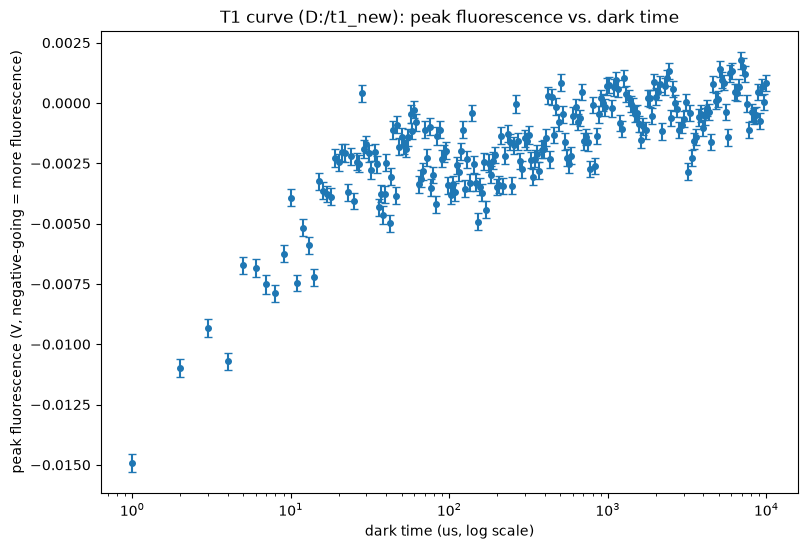

In [9]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.errorbar(new_peak_dark_times_us, new_peak_values, yerr=new_peak_errs,
            fmt="o", ms=4, capsize=3)
ax.set_xscale("log")
ax.set_xlabel("dark time (us, log scale)")
ax.set_ylabel("peak fluorescence (V, negative-going = more fluorescence)")
ax.set_title("T1 curve (D:/t1_new): peak fluorescence vs. dark time")
plt.show()

### Exponential fit (`D:/t1_new`)

In [10]:
new_fit_mask = new_peak_dark_times_us > MIN_FIT_DARK_TIME_US
new_fit_dark_times_us = new_peak_dark_times_us[new_fit_mask]
new_fit_values = new_peak_values[new_fit_mask]
new_fit_errs = new_peak_errs[new_fit_mask]
new_excluded_dark_times_us = new_peak_dark_times_us[~new_fit_mask]
new_excluded_values = new_peak_values[~new_fit_mask]

new_p0 = [new_fit_values[0] - new_fit_values[-1], 50.0, new_fit_values[-1]]
new_popt, new_pcov = curve_fit(exp_decay, new_fit_dark_times_us, new_fit_values, p0=new_p0,
                               sigma=new_fit_errs, absolute_sigma=True, maxfev=10000)
new_perr = np.sqrt(np.diag(new_pcov))

new_A_fit, new_tau_fit, new_C_fit = new_popt
new_A_err, new_tau_err, new_C_err = new_perr

print(f"fit uses {len(new_fit_dark_times_us)} points, dark time > {MIN_FIT_DARK_TIME_US}us "
      f"({new_fit_dark_times_us.min():.0f} to {new_fit_dark_times_us.max():.0f} us)")
print(f"A (amplitude)      = {new_A_fit:+.5f} +/- {new_A_err:.5f} V")
print(f"tau (T1)           = {new_tau_fit:.2f} +/- {new_tau_err:.2f} us")
print(f"C (offset/plateau) = {new_C_fit:+.5f} +/- {new_C_err:.5f} V")

fit uses 215 points, dark time > 3us (4 to 10000 us)
A (amplitude)      = -0.00362 +/- 0.00006 V
tau (T1)           = 378.22 +/- 19.45 us
C (offset/plateau) = -0.00011 +/- 0.00004 V


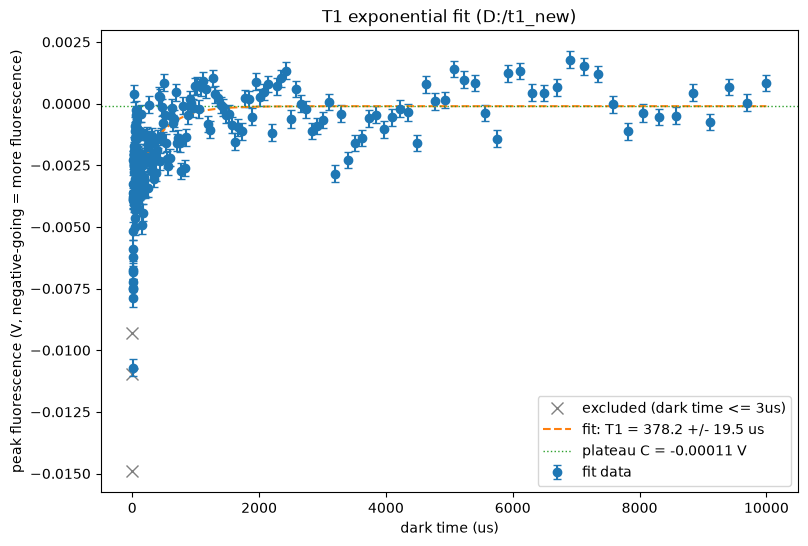

In [11]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(new_excluded_dark_times_us, new_excluded_values, "x", color="gray", ms=8,
        label=f"excluded (dark time <= {MIN_FIT_DARK_TIME_US}us)")
ax.errorbar(new_fit_dark_times_us, new_fit_values, yerr=new_fit_errs, fmt="o", color="C0",
            capsize=3, label="fit data")

new_t_smooth = np.linspace(new_fit_dark_times_us.min(), new_fit_dark_times_us.max(), 500)
ax.plot(new_t_smooth, exp_decay(new_t_smooth, *new_popt), "C1--",
        label=f"fit: T1 = {new_tau_fit:.1f} +/- {new_tau_err:.1f} us")
ax.axhline(new_C_fit, color="C2", ls=":", lw=1, label=f"plateau C = {new_C_fit:.5f} V")

ax.set_xlabel("dark time (us)")
ax.set_ylabel("peak fluorescence (V, negative-going = more fluorescence)")
ax.set_title("T1 exponential fit (D:/t1_new)")
ax.legend()
plt.show()